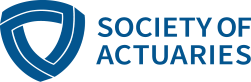

# ⛈ 02 Climate Features

|                  |                                                                                             |
| ---------------- | ------------------------------------------------------------------------------------------- |
| Title            | 02 Climate Features                                                                         |
| Case Study       | Climate-Adjusted Mortality for Selected EU countries                                        |
| Research Project | CC230 Quantifying Mortality and Morbidity Impacts from Climate Risks                       |
| Notebook         | `02_climate_features.ipynb`                                                                 |
| Authors          | Carlos Arocha, FSA, SCR                                                                     |
| Sponsor          | Catastrophe and Climate Strategic Research Program, Society of Actuaries Research Institute |
| Date             | `2026-05-11`                                                                                |
| Version          | `v1.0.0`                                                                                    |
| Questions?       | Questions regarding this notebook should be directed to the SOA project contact             |
---

## Purpose

Construct the annual country-level composite climate hazard variable $C_{t,r}$ from the processed climate layers created in Notebook 1. It does not define the scenario, countries, calibration period, projection period, age range, heat thresholds, or weights directly. Those settings are read from `data/interim/run_config.json`, and file availability is checked using the manifest files produced by Notebook 1.

The composite variable is defined as:

$C_{t,r}=w_1\cdot Z(\text{TempAnomaly}_{t,r})+w_2\cdot Z(\text{ExtremeHeatDays}_{t,r})+w_3\cdot Z(\text{HeatWaveDuration}_{t,r})$

$C_{t,r}$ is a weighted average of standardized annual country-level climate indicators. Temperature anomaly captures the broader warming signal, while extreme heat days and heatwave duration capture the frequency and persistence of acute heat stress. The weights are judgment-based and should be evaluated through sensitivity analysis. The standardization parameters are fixed using the historical ERA5 calibration period and then applied without re-centering to CMIP6 projection-period observations.

---

## Inputs

NOTE: Inputs depend on the scenario selected in Notebook `01_data_ingestion_and_preparation.ipynb`
- `CC230 Toolkit/data/processed/climate/temperature_anomaly_country_annual_combined_era5_cmip6_{SCENARIO}.csv`
- `CC230 Toolkit/data/processed/climate/heat_metrics_country_annual_combined_era5_cmip6_{SCENARIO}.csv`

---

## Outputs
- `CC230 Toolkit/data/processed/climate/C_tr_core_country_annual_combined_era5_cmip6_{SCENARIO}.csv`
- `CC230 Toolkit/data/processed/climate/C_tr_core_country_annual_era5_2004_2025_excl_2020_2021.csv`
- `CC230 Toolkit/data/processed/climate/C_tr_core_country_annual_cmip6_{SCENARIO}_2030_2050.csv`
- `CC230 Toolkit/data/processed/climate/C_tr_standardization_parameters_era5_2004_2025_excl_2020_2021.csv`
- `CC230 Toolkit/data/processed/climate/C_tr_weights.csv`

Report:
- `CC230 Toolkit/reports/{NOTEBOOK}.html`

---

## Dependencies

This notebook can be run in Google Colab or any compatible Jupyter environment, such as:

* JupyterLab
* Jupyter Notebook
* VS Code with the Jupyter extension
* Anaconda Navigator
* Kaggle Notebooks

The notebook was developed using:

* Python 3.14.5
* Required libraries installed through the setup cell below

---

## Disclaimer
The Jupyter notebooks available through this repository are provided for research, educational, and illustrative purposes only. They are not intended to constitute actuarial advice or to represent production-ready systems without further validation, customization, and governance by the user.

While reasonable efforts have been made to ensure accuracy and consistency, no guarantee is given as to completeness, fitness for a particular purpose, or compliance with applicable actuarial standards or regulatory requirements.

Users are responsible for assessing the suitability of the materials for their specific use cases and for implementing appropriate controls, validation, and documentation prior to any operational use.

---

## License
© 2026 Society of Actuaries. Except where otherwise noted, the textual content of this book is licensed under the Creative Commons Attribution–Noncommercial–Share Alike 4.0 International License (CC BY-NC-SA 4.0). Source code samples, including scripts, notebooks, and code blocks where indicated, are licensed under the MIT License, unless otherwise stated.

## Setup and Shared Configuration

In [1]:
# Setup and shared configuration

from pathlib import Path, PureWindowsPath
import json
from datetime import datetime, UTC
from typing import Any, cast

import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import sys

from matplotlib.ticker import FormatStrFormatter

PROJECT_ROOT = Path.cwd().parent.resolve()

if PROJECT_ROOT.parts[-1] != "CC230-Toolkit":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()

INTERIM_DATA_PATH = PROJECT_ROOT / "data" / "interim"
run_config_file = INTERIM_DATA_PATH / "run_config.json"
input_manifest_file = INTERIM_DATA_PATH / "input_manifest.csv"
notebook1_output_manifest_file = INTERIM_DATA_PATH / "output_manifest.csv"

NOTEBOOK_FILE = PROJECT_ROOT / "notebooks" / "02_climate_features.ipynb"    

if not run_config_file.exists():
    raise FileNotFoundError(
        f"Missing run configuration file: {run_config_file}. "
        "Run Notebook 1 first: 01_data_ingestion_and_preparation.ipynb"
    )

if not input_manifest_file.exists():
    raise FileNotFoundError(
        f"Missing input manifest file: {input_manifest_file}. "
        "Run Notebook 1 first: 01_data_ingestion_and_preparation.ipynb"
    )

with open(run_config_file, "r", encoding="utf-8") as f:
    RUN_CONFIG = json.load(f)

input_manifest = pd.read_csv(input_manifest_file)
notebook1_output_manifest = (
    pd.read_csv(notebook1_output_manifest_file)
    if notebook1_output_manifest_file.exists()
    else pd.DataFrame()
)

print("Loaded:")
print(" -", PureWindowsPath(run_config_file).name)
print(" -", PureWindowsPath(input_manifest_file).name)
if notebook1_output_manifest_file.exists():
    print(" -", notebook1_output_manifest_file)


Loaded:
 - run_config.json
 - input_manifest.csv


In [2]:
# Settings derived from Notebook 1

DATA_PATH = Path(RUN_CONFIG["data_path"])
RAW_DATA_PATH = Path(RUN_CONFIG["raw_data_path"])
PROCESSED_DATA_PATH = Path(RUN_CONFIG["processed_data_path"])
OUTPUT_PATH = Path(RUN_CONFIG["output_path"])

REPORTS_PATH = PROJECT_ROOT / "reports"

SCENARIO = RUN_CONFIG["scenario"]
COUNTRIES = RUN_CONFIG["countries"]

CALIBRATION_YEARS = [int(y) for y in RUN_CONFIG["calibration_years"]]
CALIBRATION_YEARS_LABEL = RUN_CONFIG["calibration_years_label"]
N_CALIBRATION_YEARS = int(RUN_CONFIG["n_calibration_years"])

PROJECTION_START_YEAR = int(RUN_CONFIG["projection_start_year"])
PROJECTION_END_YEAR = int(RUN_CONFIG["projection_end_year"])

HEAT_EXTREME_DAYS_PERCENTILE_COL = RUN_CONFIG["heat_extreme_days_percentile_col"]
HEATWAVE_DAYS_COL = RUN_CONFIG["heatwave_days_col"]

WEIGHTS = {
    "temp_anomaly": float(RUN_CONFIG["w_temp_anomaly"]),
    "extreme_heat_days": float(RUN_CONFIG["w_extreme_heat_days"]),
    "heatwave_duration": float(RUN_CONFIG["w_heatwave_duration"]),
}

COMPONENT_VARS = [
    "temp_anomaly",
    "extreme_heat_days",
    "heatwave_duration",
]

if not np.isclose(sum(WEIGHTS.values()), 1.0):
    raise ValueError(f"C_tr weights must sum to 1. Current sum: {sum(WEIGHTS.values()):.6f}")

files = RUN_CONFIG.get("files", {})

temp_combined_file = Path(files["temperature_anomaly_combined_file"])
heat_combined_file = Path(files["heat_metrics_combined_file"])

combined_out = (
    PROCESSED_DATA_PATH / "climate" /
    f"C_tr_core_country_annual_combined_era5_cmip6_{SCENARIO}.csv"
)

hist_out = (
    PROCESSED_DATA_PATH / "climate" /
    f"C_tr_core_country_annual_era5_{CALIBRATION_YEARS_LABEL}.csv"
)

proj_out = (
    PROCESSED_DATA_PATH / "climate" /
    f"C_tr_core_country_annual_cmip6_{SCENARIO}_{PROJECTION_START_YEAR}_{PROJECTION_END_YEAR}.csv"
)

scaling_out = (
    PROCESSED_DATA_PATH / "climate" /
    f"C_tr_standardization_parameters_era5_{CALIBRATION_YEARS_LABEL}.csv"
)

weights_out = PROCESSED_DATA_PATH / "climate" / "C_tr_weights.csv"
notebook2_output_manifest_file = INTERIM_DATA_PATH / "02_climate_features_output_manifest.csv"

(PROCESSED_DATA_PATH / "climate").mkdir(parents=True, exist_ok=True)

print("Scenario:", SCENARIO)
print("Countries:", COUNTRIES)
print("Calibration years:", CALIBRATION_YEARS)
print("Projection period:", PROJECTION_START_YEAR, "to", PROJECTION_END_YEAR)
print("Weights:", WEIGHTS)
print("Temperature file:", PureWindowsPath(temp_combined_file).name)
print("Heat metrics file:", PureWindowsPath(heat_combined_file).name)


Scenario: ssp5_8_5
Countries: ['ES', 'FR', 'IT']
Calibration years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024, 2025]
Projection period: 2030 to 2060
Weights: {'temp_anomaly': 0.2, 'extreme_heat_days': 0.7, 'heatwave_duration': 0.1}
Temperature file: temperature_anomaly_country_annual_combined_era5_cmip6_ssp5_8_5.csv
Heat metrics file: heat_metrics_country_annual_combined_era5_cmip6_ssp5_8_5.csv


## Helper Functions and Input Checks

In [3]:
# Helper functions and input checks

def ensure_columns(df, required_cols, label):
    missing = set(required_cols) - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing required columns: {sorted(missing)}")

def add_period_type(df):
    df = df.copy()
    if "period_type" not in df.columns:
        df["period_type"] = np.where(
            df["source"].astype(str).str.upper().eq("ERA5"),
            "historical",
            "projection",
        )
    return df


def to_float_array(series: "pd.Series[Any]") -> npt.NDArray[np.float64]:
    """Return a numeric NumPy float64 array from a pandas Series.

    This keeps NumPy calls such as np.polyfit and np.linspace clear to Pylance.
    """
    return cast(
        npt.NDArray[np.float64],
        series.to_numpy(dtype=np.float64, copy=True, na_value=np.nan),
    )

def path_to_project_relative(path):
    path = Path(path)
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def register_file(role, path, file_type="csv", required=True, stage="output", notes=None):
    path = Path(path)
    return {
        "stage": stage,
        "role": role,
        "file_name": path.name,
        "relative_path": path_to_project_relative(path),
        "absolute_path": str(path),
        "file_type": file_type,
        "required": bool(required),
        "exists": path.exists(),
        "notes": notes,
    }

def require_file(path, label):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found for {label}: {path}. "
            "Run Notebook 1 and review the Notebook 1 output manifest."
        )
    return path

require_file(temp_combined_file, "temperature anomaly input")
require_file(heat_combined_file, "heat metrics input")

if not notebook1_output_manifest.empty:
    print("Notebook 1 output manifest:")

print("Required Notebook 2 input files were found.")

Required Notebook 2 input files were found.


## Load Component Datasets

In [4]:
# Load processed component datasets

temp_raw = pd.read_csv(temp_combined_file)
heat_raw = pd.read_csv(heat_combined_file)

temp_raw = add_period_type(temp_raw)
heat_raw = add_period_type(heat_raw)

temp_raw["year"] = pd.to_numeric(temp_raw["year"], errors="coerce").astype("Int64")
heat_raw["year"] = pd.to_numeric(heat_raw["year"], errors="coerce").astype("Int64")

temp_raw = temp_raw[temp_raw["country"].isin(COUNTRIES)].copy()
heat_raw = heat_raw[heat_raw["country"].isin(COUNTRIES)].copy()

temp_raw = temp_raw[
    (
        temp_raw["period_type"].eq("historical")
        & temp_raw["year"].isin(CALIBRATION_YEARS)
    )
    | (
        temp_raw["period_type"].eq("projection")
        & temp_raw["year"].between(PROJECTION_START_YEAR, PROJECTION_END_YEAR)
    )
].copy()

heat_raw = heat_raw[
    (
        heat_raw["period_type"].eq("historical")
        & heat_raw["year"].isin(CALIBRATION_YEARS)
    )
    | (
        heat_raw["period_type"].eq("projection")
        & heat_raw["year"].between(PROJECTION_START_YEAR, PROJECTION_END_YEAR)
    )
].copy()

print("Temperature anomaly shape:", temp_raw.shape)
print("Heat metrics shape:", heat_raw.shape)

Temperature anomaly shape: (153, 8)
Heat metrics shape: (153, 13)


## Prepare the Climate Components

In [5]:
# Prepare component variables for C_{t,r}

ensure_columns(
    temp_raw,
    ["country", "year", "source", "scenario", "period_type", "temperature_anomaly_c"],
    "Temperature anomaly data",
)

ensure_columns(
    heat_raw,
    ["country", "year", "source", "scenario", "period_type", HEAT_EXTREME_DAYS_PERCENTILE_COL, HEATWAVE_DAYS_COL],
    "Heat metrics data",
)

temp_component = (
    temp_raw[["country", "year", "source", "scenario", "period_type", "temperature_anomaly_c"]]
    .rename(columns={"temperature_anomaly_c": "temp_anomaly"})
    .copy()
)

heat_component = (
    heat_raw[["country", "year", "source", "scenario", "period_type", HEAT_EXTREME_DAYS_PERCENTILE_COL, HEATWAVE_DAYS_COL]]
    .rename(columns={
        HEAT_EXTREME_DAYS_PERCENTILE_COL: "extreme_heat_days",
        HEATWAVE_DAYS_COL: "heatwave_duration",
    })
    .copy()
)

merge_keys = ["country", "year", "source", "scenario", "period_type"]

climate_components = temp_component.merge(
    heat_component,
    on=merge_keys,
    how="inner",
    validate="one_to_one",
)

climate_components = climate_components[
    climate_components["period_type"].eq("historical")
    | (
        climate_components["period_type"].eq("projection")
        & climate_components["scenario"].astype(str).eq(SCENARIO)
    )
].copy()

climate_components["year"] = climate_components["year"].astype(int)

coverage_check = (
    climate_components
    .groupby(["country", "period_type"], as_index=False)
    .agg(
        min_year=("year", "min"),
        max_year=("year", "max"),
        n_years=("year", "nunique"),
    )
)

print("Combined climate components shape:", climate_components.shape)

Combined climate components shape: (153, 8)


## Standardization

Each component is standardized by country using the historical calibration period 2004-2025 (excluding 2020 and 2021):

$Z(X_{t,r}) = \dfrac{X_{t,r} - \mu_{r}}{\sigma_{r}}$

where $\mu_r$ and $\sigma_r$ are estimated from ERA5 historical observations. The same standardization parameters are then applied to CMIP6 projection-period values.


In [6]:
# Stardardize components

calibration_mask = (
    climate_components["period_type"].eq("historical")
    & climate_components["year"].isin(CALIBRATION_YEARS)
)

calibration_data = climate_components.loc[calibration_mask].copy()

calibration_coverage = (
    calibration_data
    .groupby("country", as_index=False)
    .agg(
        n_years=("year", "nunique"),
        min_year=("year", "min"),
        max_year=("year", "max"),
    )
)

bad_coverage = calibration_coverage[
    calibration_coverage["n_years"] != N_CALIBRATION_YEARS
].copy()

if not bad_coverage.empty:
    display(bad_coverage)
    raise ValueError(
        "Some countries do not have the expected calibration years. "
        "Review the output of Notebook 1 and CALIBRATION_YEARS."
    )

scaling_rows = []
for country, g in calibration_data.groupby("country"):
    for var in COMPONENT_VARS:
        mean_val = g[var].mean()
        sd_val = g[var].std(ddof=0)

        #if pd.isna(sd_val) or np.isclose(sd_val, 0.0):
        #    raise ValueError(
        #        f"Standard deviation is zero or missing for country={country}, variable={var}."
        #    )

        scaling_rows.append({
            "country": country,
            "variable": var,
            "mean": mean_val,
            "sd": sd_val,
            "source": "ERA5",
            "calibration_years": ",".join(map(str, CALIBRATION_YEARS)),
            "calibration_years_label": CALIBRATION_YEARS_LABEL,
        })

scaling_params = pd.DataFrame(scaling_rows)

print("Components successfully standardized.")

Components successfully standardized.


In [7]:
# Apply standardization to historical and projection data using 2004-2025 (excl. 2020 & 2021) parameters

climate_z = climate_components.copy()

for var in COMPONENT_VARS:
    params = (
        scaling_params[scaling_params["variable"].eq(var)]
        [["country", "mean", "sd"]]
        .rename(columns={
            "mean": f"{var}_mean",
            "sd": f"{var}_sd",
        })
    )

    climate_z = climate_z.merge(
        params,
        on="country",
        how="left",
        validate="many_to_one",
    )

    climate_z[f"z_{var}"] = (
        climate_z[var] - climate_z[f"{var}_mean"]
    ) / climate_z[f"{var}_sd"]

print("Standardization applied successfully.")

Standardization applied successfully.


## Construction of $C_{t, r}$

$C_{t,r}=w_1\cdot Z(\text{TempAnomaly}_{t, r})\,+\,w_2\cdot Z(\text{ExtremeHeatDays}_{t, r})\,+\,w_3\cdot Z(\text{HeatWaveDuration}_{t, r})$

Weights correspond to:  
$w_1 \rightarrow$ long-term warming  
$w_2 \rightarrow$ frequency of extreme heat  
$w_3 \rightarrow$ persistence of heat episodes

In [8]:
# Construct C_{t,r}

climate_z["C_tr_core"] = (
    WEIGHTS["temp_anomaly"] * climate_z["z_temp_anomaly"]
    + WEIGHTS["extreme_heat_days"] * climate_z["z_extreme_heat_days"]
    + WEIGHTS["heatwave_duration"] * climate_z["z_heatwave_duration"]
)

climate_z["w_temp_anomaly"] = WEIGHTS["temp_anomaly"]
climate_z["w_extreme_heat_days"] = WEIGHTS["extreme_heat_days"]
climate_z["w_heatwave_duration"] = WEIGHTS["heatwave_duration"]

climate_z["C_tr_definition"] = " + ".join(
    f"{weight:.2f}*z_{component}"
    for component, weight in WEIGHTS.items()
)

climate_z["standardization_period"] = CALIBRATION_YEARS_LABEL
climate_z["standardization_source"] = "ERA5"

output_cols = [
    "country",
    "year",
    "source",
    "scenario",
    "period_type",
    "temp_anomaly",
    "extreme_heat_days",
    "heatwave_duration",
    "z_temp_anomaly",
    "z_extreme_heat_days",
    "z_heatwave_duration",
    "C_tr_core",
    "w_temp_anomaly",
    "w_extreme_heat_days",
    "w_heatwave_duration",
    "C_tr_definition",
    "standardization_period",
    "standardization_source",
]

C_tr = climate_z[output_cols].sort_values(
    ["country", "period_type", "year"]
).reset_index(drop=True)

print("C_tr output shape:", C_tr.shape)

C_tr output shape: (153, 18)


## Save Processed Climate Feature Outputs

In [9]:
# Save combined, historical, projection, scaling, and weight outputs

C_tr.to_csv(combined_out, index=False)

C_tr_hist = C_tr[
    C_tr["period_type"].eq("historical")
    & C_tr["year"].isin(CALIBRATION_YEARS)
].copy()

C_tr_proj = C_tr[
    C_tr["period_type"].eq("projection")
    & C_tr["scenario"].astype(str).eq(SCENARIO)
    & C_tr["year"].between(PROJECTION_START_YEAR, PROJECTION_END_YEAR)
].copy()

C_tr_hist.to_csv(hist_out, index=False)
C_tr_proj.to_csv(proj_out, index=False)
scaling_params.to_csv(scaling_out, index=False)

weights_df = pd.DataFrame([
    {
        "component": component,
        "weight": weight,
        "scenario": SCENARIO,
        "created_at_utc": datetime.now(UTC).isoformat(),
    }
    for component, weight in WEIGHTS.items()
])

weights_df.to_csv(weights_out, index=False)

print("Saved Notebook 2 outputs:")
for file_path in [combined_out, hist_out, proj_out, scaling_out, weights_out]:
    print(f"  - {PureWindowsPath(file_path).name}")

Saved Notebook 2 outputs:
  - C_tr_core_country_annual_combined_era5_cmip6_ssp5_8_5.csv
  - C_tr_core_country_annual_era5_2004_2025_excl_2020_2021.csv
  - C_tr_core_country_annual_cmip6_ssp5_8_5_2030_2060.csv
  - C_tr_standardization_parameters_era5_2004_2025_excl_2020_2021.csv
  - C_tr_weights.csv


## Validation Checks

In [10]:
# Checks

historical_country_check = (
    C_tr_hist
    .groupby("country")[["z_temp_anomaly", "z_extreme_heat_days", "z_heatwave_duration", "C_tr_core"]]
    .agg(["mean", "std"])
)

period_check = (
    C_tr
    .groupby(["country", "period_type"], as_index=False)["C_tr_core"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

C_tr_check = C_tr.copy()
C_tr_check["C_tr_reconstructed"] = (
    C_tr_check["w_temp_anomaly"] * C_tr_check["z_temp_anomaly"]
    + C_tr_check["w_extreme_heat_days"] * C_tr_check["z_extreme_heat_days"]
    + C_tr_check["w_heatwave_duration"] * C_tr_check["z_heatwave_duration"]
)

max_reconstruction_error = (
    C_tr_check["C_tr_core"] - C_tr_check["C_tr_reconstructed"]
).abs().max()

print(f"Maximum C_tr reconstruction error: {max_reconstruction_error:.12f}")

if max_reconstruction_error > 1e-10:
    raise ValueError("C_tr reconstruction check failed.")

Maximum C_tr reconstruction error: 0.000000000000


## Diagnostic Visuals

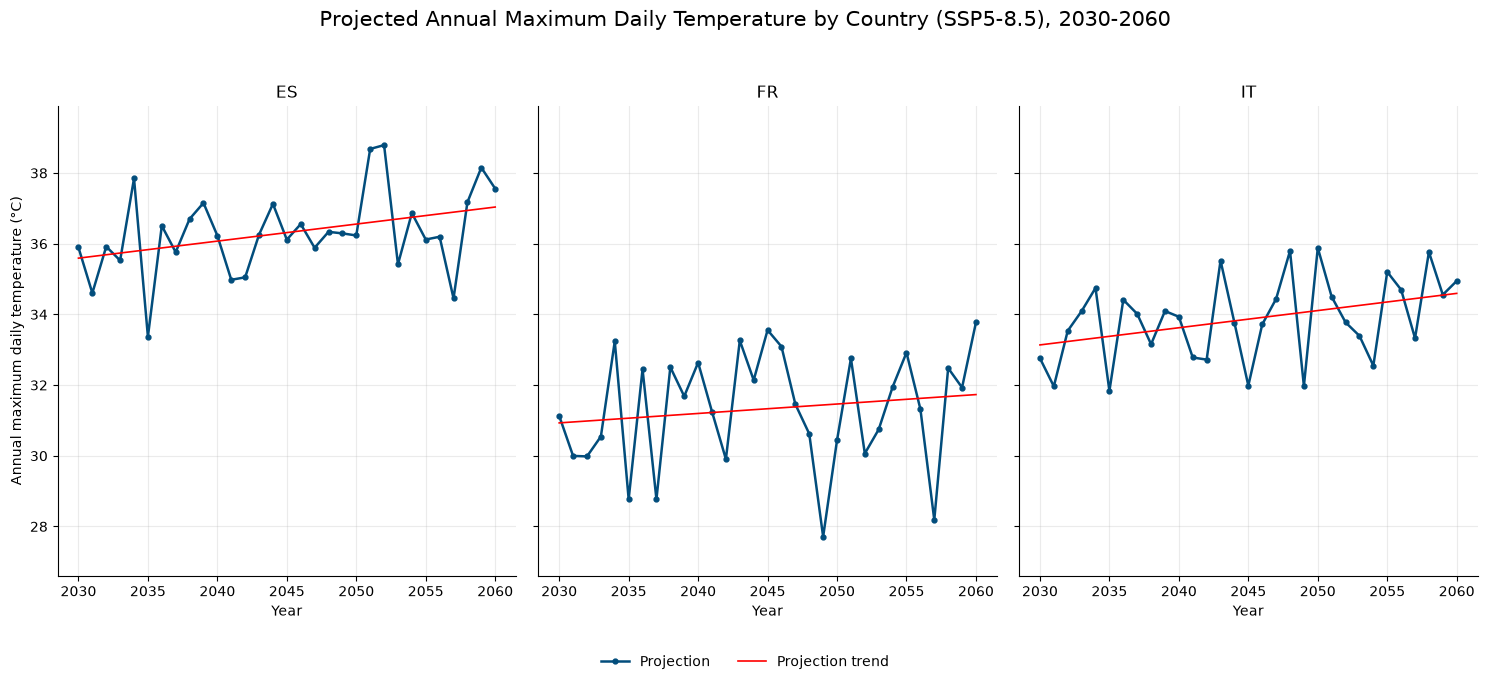

In [11]:
# Visual A: Projected Annual Maximum Temperature

# NOTE: select "c" or "f", for temperature units

TEMP_UNITS = "c" # "f" 

ANNUAL_MAX_TMAX_C_COL = "annual_max_daily_tmax_c"
ANNUAL_MAX_TMAX_F_COL = "annual_max_daily_tmax_f"

heat = heat_raw.copy()
heat["year"] = pd.to_numeric(heat["year"], errors="coerce").astype(int)

# Create Fahrenheit version if needed
if ANNUAL_MAX_TMAX_C_COL in heat.columns:
    heat[ANNUAL_MAX_TMAX_F_COL] = heat[ANNUAL_MAX_TMAX_C_COL] * 1.8 + 32
else:
    raise ValueError(
        f"Expected column '{ANNUAL_MAX_TMAX_C_COL}' was not found in heat_raw."
    )

metric = f"annual_max_daily_tmax_{TEMP_UNITS}"
metric_label = f"Annual maximum daily temperature (°{TEMP_UNITS.upper()})"

heat_plot = heat[
    heat["country"].isin(COUNTRIES)
    & heat["period_type"].eq("projection")
].copy()

values = pd.to_numeric(heat_plot[metric], errors="coerce").dropna()

if values.empty:
    y_limits = (0.0, 1.0)
else:
    y_min_raw = float(values.min())
    y_max_raw = float(values.max())
    y_range = y_max_raw - y_min_raw
    y_pad = 0.10 * y_range if y_range > 0 else 1.0

    y_limits = (
        y_min_raw - y_pad,
        y_max_raw + y_pad
    )

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(COUNTRIES),
    figsize=(15, 6),
    sharex=True,
    sharey=True,
)

if len(COUNTRIES) == 1:
    axes = np.array([axes])

palette = {
    "projection": "#024D7C",
    "projection_trend": "red",
}

for col_idx, country in enumerate(COUNTRIES):

    ax = axes[col_idx]

    g = (
        heat_plot[heat_plot["country"].eq(country)]
        .sort_values("year")
        .copy()
    )

    if g.empty:
        ax.set_title(country, fontsize=12)
        ax.text(
            0.5,
            0.5,
            "No projection data",
            ha="center",
            va="center",
            transform=ax.transAxes
        )
        continue

    ax.plot(
        g["year"],
        g[metric],
        marker="o",
        markersize=3.5,
        linewidth=1.8,
        color=palette["projection"],
        label="Projection" if col_idx == 0 else None,
    )

    trend_data = g[["year", metric]].copy()
    trend_data["year"] = pd.to_numeric(trend_data["year"], errors="coerce")
    trend_data[metric] = pd.to_numeric(trend_data[metric], errors="coerce")
    trend_data = trend_data.dropna(subset=["year", metric])

    if trend_data.shape[0] >= 2:

        x = to_float_array(trend_data["year"])
        y = to_float_array(trend_data[metric])

        slope, intercept = np.polyfit(x, y, deg=1)

        x_trend = np.linspace(float(x.min()), float(x.max()), 100)
        y_trend = slope * x_trend + intercept

        ax.plot(
            x_trend,
            y_trend,
            linestyle="-",
            linewidth=1.2,
            color=palette["projection_trend"],
            label="Projection trend" if col_idx == 0 else None,
        )

    ax.set_ylim(*y_limits)

    ax.set_title(country, fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel(metric_label if col_idx == 0 else "")

    ax.grid(True, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

scenario_title = SCENARIO.upper().replace("_", "-", 1).replace("_", ".")

fig.suptitle(
    f"Projected Annual Maximum Daily Temperature by Country ({scenario_title}), {PROJECTION_START_YEAR}-{PROJECTION_END_YEAR}",
    fontsize=15,
    y=1.04
)

fig.legend(
    frameon=False,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.08)
)

plt.tight_layout()
plt.show()

fig.savefig(
    OUTPUT_PATH / f"annual_max_daily_temperature_projection_({TEMP_UNITS})_{SCENARIO}_{CALIBRATION_YEARS_LABEL}.svg",
    dpi=300,
    bbox_inches="tight"
)


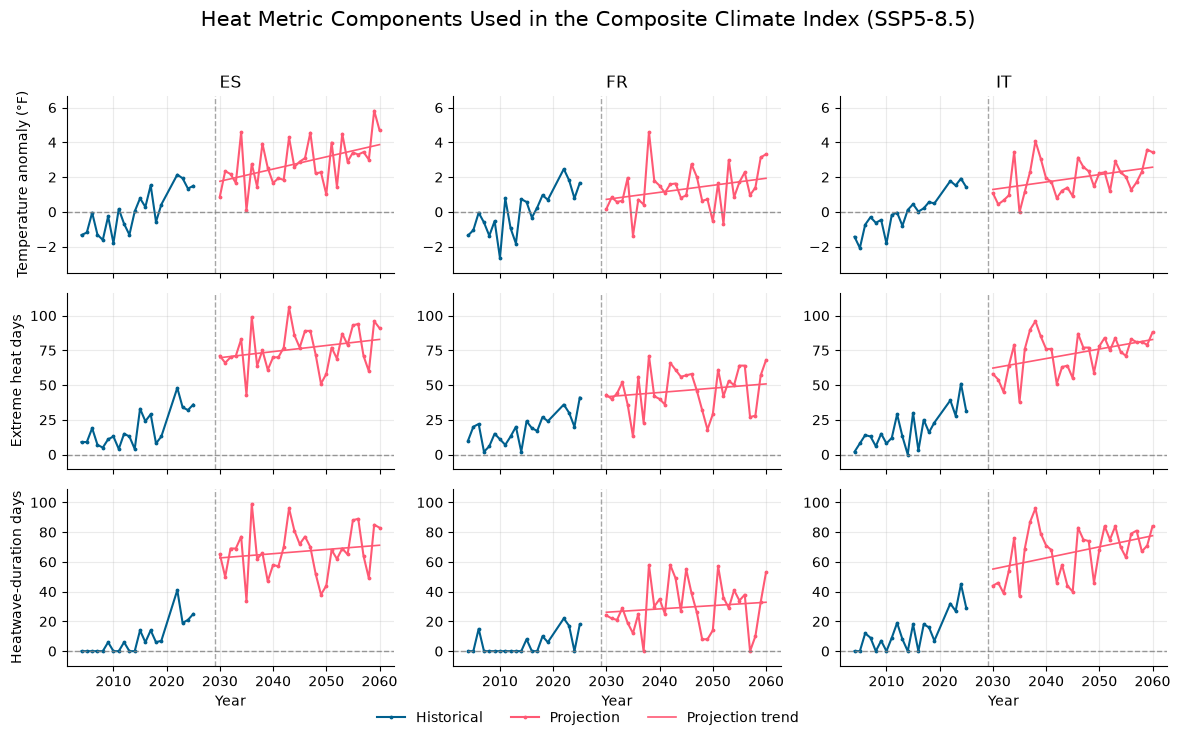

In [12]:
# Visual B:

# NOTE: select "c" or "f", for temperature units

TEMP_UNITS = "f" # "f" 

heat = heat_raw.copy()
heat["year"] = pd.to_numeric(heat["year"], errors="coerce").astype(int)

if "annual_mean_daily_tmax_c" in heat.columns:
    hist_mean_tmax = (
        heat[heat["period_type"].eq("historical")]
        .groupby("country")["annual_mean_daily_tmax_c"]
        .mean()
        .rename("historical_mean_tmax_c")
        .reset_index()
    )

    heat = heat.merge(hist_mean_tmax, on="country", how="left")
    heat["temp_anomaly_c"] = (
        heat["annual_mean_daily_tmax_c"]
        - heat["historical_mean_tmax_c"]
    )
else:
    heat["temp_anomaly_c"] = np.nan

heat["temp_anomaly_f"] = heat["temp_anomaly_c"] * 1.8    

metrics = {
    f"temp_anomaly_{TEMP_UNITS}": f"Temperature anomaly (°{TEMP_UNITS.upper()})",
    HEAT_EXTREME_DAYS_PERCENTILE_COL: "Extreme heat days",
    HEATWAVE_DAYS_COL: "Heatwave-duration days",
}

heat_plot = heat[heat["country"].isin(COUNTRIES)].copy()

y_limits = {}

for metric in metrics:
    values = pd.to_numeric(heat_plot[metric], errors="coerce").dropna()

    if values.empty:
        y_limits[metric] = (0.0, 1.0)
    else:
        y_min_raw = float(values.min())
        y_max_raw = float(values.max())
        y_range = y_max_raw - y_min_raw
        y_pad = 0.10 * y_range if y_range > 0 else 1.0

        y_limits[metric] = (
            min(0, y_min_raw - y_pad),
            max(0, y_max_raw + y_pad)
        )

fig, axes = plt.subplots(
    nrows=len(metrics),
    ncols=len(COUNTRIES),
    figsize=(12, 7),
    sharex=True,
)

if len(COUNTRIES) == 1:
    axes = np.array(axes).reshape(len(metrics), 1)

palette = {
    "historical": "#00608E",
    "projection": "#ff5974",
    "projection_trend": "#ff5974",
}

for row_idx, (metric, metric_label) in enumerate(metrics.items()):

    for col_idx, country in enumerate(COUNTRIES):

        ax = axes[row_idx, col_idx]

        g_country = heat_plot[
            heat_plot["country"].eq(country)
        ].copy()

        for period_type in ["historical", "projection"]:

            g = (
                g_country[
                    g_country["period_type"].eq(period_type)
                ]
                .sort_values("year")
                .copy()
            )

            if g.empty:
                continue

            ax.plot(
                g["year"],
                g[metric],
                marker=".",
                markersize=3.5,                
                color=palette[period_type],
                label=(
                    period_type.capitalize()
                    if row_idx == 0 and col_idx == 0
                    else None
                ),
            )

            if period_type == "projection":

                trend_data = g[["year", metric]].copy()
                trend_data["year"] = pd.to_numeric(trend_data["year"], errors="coerce")
                trend_data[metric] = pd.to_numeric(trend_data[metric], errors="coerce")
                trend_data = trend_data.dropna(subset=["year", metric])

                if trend_data.shape[0] >= 2:

                    x = to_float_array(trend_data["year"])
                    y = to_float_array(trend_data[metric])

                    slope, intercept = np.polyfit(x, y, deg=1)

                    x_trend = np.linspace(float(x.min()), float(x.max()), 100)
                    y_trend = slope * x_trend + intercept

                    ax.plot(
                        x_trend,
                        y_trend,
                        linestyle="-",
                        linewidth=1.2,
                        color=palette["projection_trend"],
                        label=(
                            "Projection trend"
                            if row_idx == 0 and col_idx == 0
                            else None
                        ),
                    )

        ax.axhline(
            0,
            linestyle="--",
            linewidth=1.0,
            color="gray",
            alpha=0.8
        )

        ax.axvline(
            PROJECTION_START_YEAR - 1,
            linestyle="--",
            linewidth=1.0,
            color="gray",
            alpha=0.7
        )

        ax.set_ylim(*y_limits[metric])

        ax.set_title(
            country if row_idx == 0 else "",
            fontsize=12
        )

        ax.set_ylabel(
            metric_label if col_idx == 0 else ""
        )

        ax.grid(True, alpha=0.25)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

for ax in axes[-1, :]:
    ax.set_xlabel("Year")

scenario_title = SCENARIO.upper().replace("_", "-", 1).replace("_", ".")

fig.suptitle(
    f"Heat Metric Components Used in the Composite Climate Index ({scenario_title})",
    fontsize=15,
    y=1.02
)

fig.legend(
    frameon=False,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.show()

fig.savefig(
    OUTPUT_PATH / f"heat_metric_components_({TEMP_UNITS})_{SCENARIO}_{CALIBRATION_YEARS_LABEL}.svg",
    dpi=300,
    bbox_inches="tight"
)

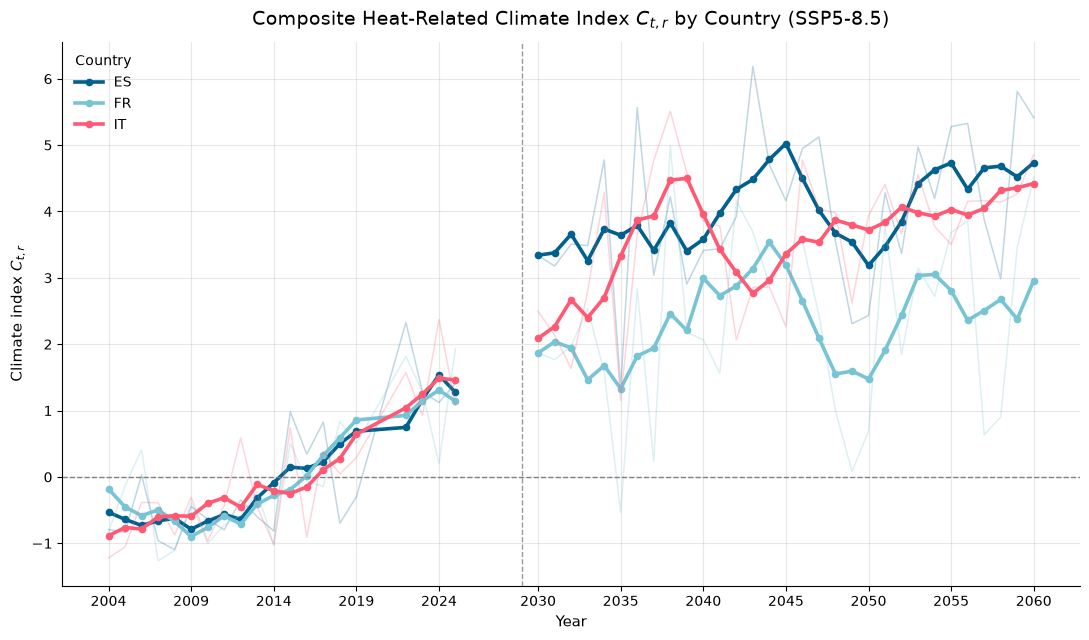

In [13]:
# Visual C: Composite C_{t,r} by country

climate_index = C_tr[C_tr["country"].isin(COUNTRIES)].copy()

climate_index = climate_index[
    climate_index["period_type"].eq("historical")
    | (
        climate_index["period_type"].eq("projection")
        & climate_index["scenario"].astype(str).eq(SCENARIO)
    )
].copy()

climate_index["year"] = pd.to_numeric(climate_index["year"], errors="coerce").astype(int)
climate_index["C_tr_core"] = pd.to_numeric(climate_index["C_tr_core"], errors="coerce")
climate_index = climate_index.sort_values(["country", "period_type", "year"]).copy()

climate_index["C_tr_core_5yr"] = (
    climate_index
    .groupby(["country", "period_type"])["C_tr_core"]
    .transform(lambda x: x.rolling(window=5, min_periods=1, center=True).mean())
)

country_colors = {
    "ES": "#00608E",
    "IT": "#ff5974",
    "FR": "#77c4d5",
    "DE": "#fdce07",
    "NL": "#babf33",
}

fig, ax = plt.subplots(figsize=(11, 6.5))

for country in COUNTRIES:
    g_country = climate_index[climate_index["country"].eq(country)].copy()

    for period_type in ["historical", "projection"]:
        g = g_country[g_country["period_type"].eq(period_type)].sort_values("year").copy()
        if g.empty:
            continue

        ax.plot(
            g["year"],
            g["C_tr_core"],
            color=country_colors.get(country, "gray"),
            linewidth=1.1,
            alpha=0.25,
        )

        ax.plot(
            g["year"],
            g["C_tr_core_5yr"],
            color=country_colors.get(country, "gray"),
            linewidth=2.6,
            marker="o",
            markersize=4.5,
            label=country if period_type == "projection" else None,
        )

ax.axhline(0, linestyle="--", linewidth=1.0, color="gray")
ax.axvline(PROJECTION_START_YEAR - 1, linestyle="--", linewidth=1.0, color="gray", alpha=0.8)
ax.set_title(fr"Composite Heat-Related Climate Index $C_{{t,r}}$ by Country ({scenario_title})", fontsize=14, pad=12)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel(r"Climate index $C_{t,r}$", fontsize=11)

xticks = sorted(set(
    list(range(min(CALIBRATION_YEARS), max(CALIBRATION_YEARS) + 1, 5))
    + list(range(PROJECTION_START_YEAR, PROJECTION_END_YEAR + 1, 5))
))
ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Country", frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

fig.savefig(
    OUTPUT_PATH / f"C_tr_by_country_{SCENARIO}_{CALIBRATION_YEARS_LABEL}.svg",
    dpi=300,
    bbox_inches="tight"
)

## Final Checks and Next Steps

In [14]:
# Output manifest and completion message

output_records = [
    register_file(
        role="climate_index_combined",
        path=combined_out,
        notes="Combined historical and projected C_tr climate index",
    ),
    register_file(
        role="climate_index_historical",
        path=hist_out,
        notes="Historical C_tr values for calibration years selected in Notebook 1",
    ),
    register_file(
        role="climate_index_projection",
        path=proj_out,
        notes=f"Projected C_tr values for {SCENARIO}",
    ),
    register_file(
        role="climate_index_standardization_parameters",
        path=scaling_out,
        notes="Country-specific standardization parameters for C_tr components",
    ),
    register_file(
        role="climate_index_weights",
        path=weights_out,
        notes="Weights used to construct C_tr",
    ),
]

notebook2_output_manifest = pd.DataFrame(output_records)
notebook2_output_manifest.to_csv(notebook2_output_manifest_file, index=False)

missing_outputs = notebook2_output_manifest[
    notebook2_output_manifest["required"].eq(True)
    & notebook2_output_manifest["exists"].eq(False)
].copy()

if not missing_outputs.empty:
    display(missing_outputs[["role", "file_name", "absolute_path"]])
    raise FileNotFoundError(
        "One or more expected Notebook 2 outputs were not created. Review the cells above."
    )

print("Saved Notebook 2 output manifest:")
print(PureWindowsPath(notebook2_output_manifest_file).name)

print("\n" + "=" * 78)
print("✅ NOTEBOOK 2 COMPLETE")
print("=" * 78)
print("Please review the climate-index output files listed below before proceeding:\n.")

print("Next step: run Notebook 3 — 03_baseline_mortality_model.ipynb")
print("=" * 78)

# Create report
subprocess.run(
    [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        str(NOTEBOOK_FILE),
        "--to",
        "html",
        "--no-input",
        "--output-dir",
        str(REPORTS_PATH),
    ],
    check=True,
)

Saved Notebook 2 output manifest:
02_climate_features_output_manifest.csv

✅ NOTEBOOK 2 COMPLETE
Please review the climate-index output files listed below before proceeding:
.
Next step: run Notebook 3 — 03_baseline_mortality_model.ipynb


CompletedProcess(args=['c:\\venvs\\CC230\\Scripts\\python.exe', '-m', 'jupyter', 'nbconvert', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230-Toolkit\\notebooks\\02_climate_features.ipynb', '--to', 'html', '--no-input', '--output-dir', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230-Toolkit\\reports'], returncode=0)